In [1]:
import datetime as dt
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import warnings
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
from IPython.display import Image

In [2]:
pd.options.display.float_format = "{:,.2f}".format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

In [3]:
energy = pd.read_csv("data/energy.csv", parse_dates=["timestamp"])
energy.index = energy["timestamp"]
energy = energy.reindex(
    pd.date_range(min(energy["timestamp"]), max(energy["timestamp"]), freq="h")
)
energy.drop(["temp", "timestamp"], axis=1, inplace=True)
energy.head(10)

,load
2012-01-01 00:00:00,"2,698.00"
2012-01-01 01:00:00,"2,558.00"
2012-01-01 02:00:00,"2,444.00"
2012-01-01 03:00:00,"2,402.00"
2012-01-01 04:00:00,"2,403.00"
2012-01-01 05:00:00,"2,453.00"
2012-01-01 06:00:00,"2,560.00"
2012-01-01 07:00:00,"2,719.00"
2012-01-01 08:00:00,"2,916.00"
2012-01-01 09:00:00,"3,105.00"


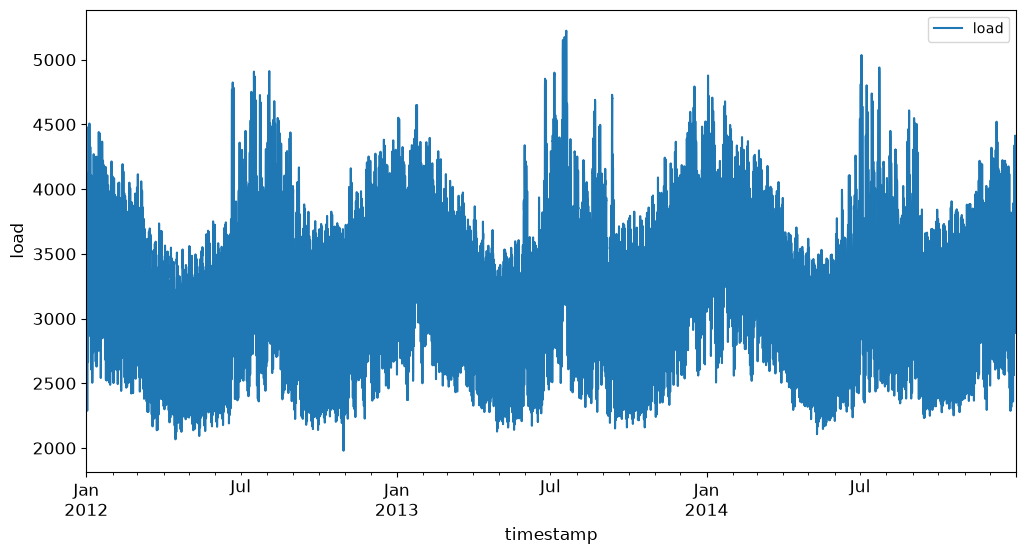

In [4]:
energy.plot(y="load", subplots=True, figsize=(12,6), fontsize=12)
plt.xlabel("timestamp", fontsize=12)
plt.ylabel("load", fontsize=12)
plt.show()

In [5]:
train_start_date = '2014-11-01 00:00:00'
test_start_date = '2014-12-30 00:00:00'

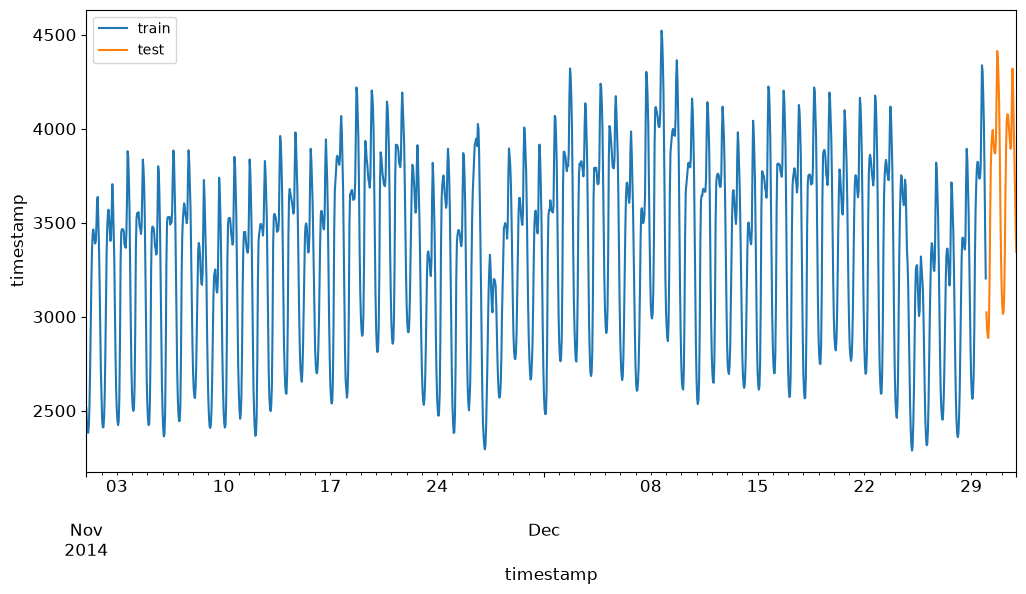

In [6]:
energy[(energy.index >= train_start_date) & (energy.index < test_start_date)][["load"]].rename(columns={"load" : "train"})\
    .join(energy[test_start_date:][["load"]].rename(columns={"load" : "test"}), how="outer")\
    .plot(y=["train", "test"], figsize=(12,6), fontsize=12)
plt.xlabel("timestamp", fontsize=12)
plt.ylabel("timestamp", fontsize=12)
plt.show()

In [7]:
train = energy.copy()[(energy.index >= train_start_date) & (energy.index < test_start_date)][["load"]]
train.shape

(1416, 1)

In [8]:
test = energy.copy()[(energy.index >= test_start_date)][["load"]]
test.shape

(48, 1)

In [9]:
scaler = MinMaxScaler()
train["load"] = scaler.fit_transform(train)
train.head()

,load
2014-11-01 00:00:00,0.10
2014-11-01 01:00:00,0.07
2014-11-01 02:00:00,0.05
2014-11-01 03:00:00,0.04
2014-11-01 04:00:00,0.06


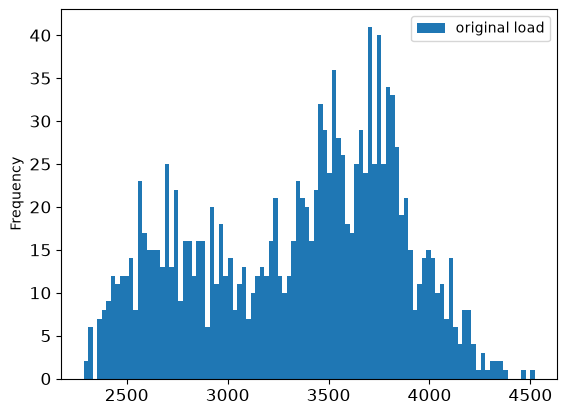

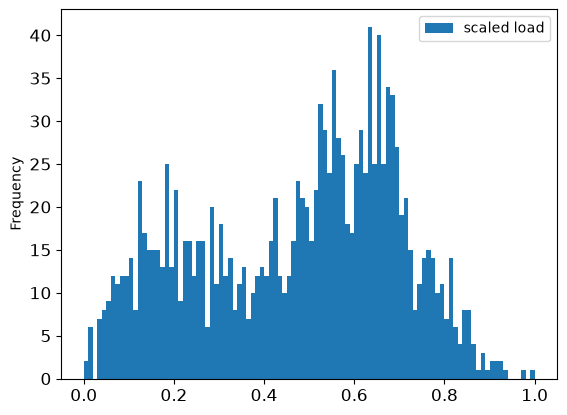

In [10]:
energy[(energy.index >= train_start_date) & (energy.index < test_start_date)][['load']].rename(columns={'load':'original load'}).plot.hist(bins=100, fontsize=12)
train.rename(columns={'load':'scaled load'}).plot.hist(bins=100, fontsize=12)
plt.show()

In [11]:
test["load"] = scaler.fit_transform(test)
test.head()

,load
2014-12-30 00:00:00,0.09
2014-12-30 01:00:00,0.03
2014-12-30 02:00:00,0.01
2014-12-30 03:00:00,0.00
2014-12-30 04:00:00,0.05


In [12]:
HORIZON = 3
order = (4, 1, 0)
seasonal_order = (1, 1, 0, 24)
model = SARIMAX(endog=train, order=order, seasonal_order=seasonal_order)
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                 1416
Model:             SARIMAX(4, 1, 0)x(1, 1, 0, 24)   Log Likelihood                3477.241
Date:                            Wed, 07 Oct 2026   AIC                          -6942.481
Time:                                    16:05:37   BIC                          -6911.055
Sample:                                11-01-2014   HQIC                         -6930.730
                                     - 12-29-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8406      0.016     52.113      0.000       0.809       0.872
ar.L2         -0.5225      0.034   

In [23]:
test_shifted = test.copy()

for t in range(1, HORIZON):
    test_shifted["load+" + str(t)] = test_shifted["load"].shift(-t, freq="h")

test_shifted.dropna(inplace=True, how="any")
test_shifted.head()

,load,load+1,load+2
2014-12-30 00:00:00,0.09,0.03,0.01
2014-12-30 01:00:00,0.03,0.01,0.00
2014-12-30 02:00:00,0.01,0.00,0.05
2014-12-30 03:00:00,0.00,0.05,0.20
2014-12-30 04:00:00,0.05,0.20,0.44


In [18]:
training_window = 720
train_ts = train["load"]
test_ts = test_shifted
history = [x for x in train_ts]
history = history[(-training_window):]
predictions = list()
order = (2, 1, 0)
seasonal_order = (1, 1, 0, 24)

for t in range(test_ts.shape[0]):
    model = SARIMAX(endog=history, order=order, seasonal_order=seasonal_order)
    fitted_model = model.fit()
    y_pred = fitted_model.forecast(steps=HORIZON)
    predictions.append(y_pred)
    obs = list(test_ts.iloc[t])
    history.append(obs[0])
    history.pop(0)
    print(test_ts.index[t])
    print(f"{t+1} : Predicted - {y_pred}, expected - {obs}")

2014-12-30 00:00:00
1 : Predicted - [0.32 0.29 0.28], expected - [0.08971840209561233, 0.03208906352324825, 0.00851342501637209]
2014-12-30 01:00:00
2 : Predicted - [-0.14 -0.21 -0.16], expected - [0.03208906352324825, 0.00851342501637209, 0.0]
2014-12-30 02:00:00
3 : Predicted - [0.1  0.18 0.24], expected - [0.00851342501637209, 0.0, 0.05042567125081865]
2014-12-30 03:00:00
4 : Predicted - [0.02 0.06 0.16], expected - [0.0, 0.05042567125081865, 0.20497707924034048]
2014-12-30 04:00:00
5 : Predicted - [0.03 0.13 0.28], expected - [0.05042567125081865, 0.20497707924034048, 0.44007858546168954]
2014-12-30 05:00:00
6 : Predicted - [0.16 0.32 0.43], expected - [0.20497707924034048, 0.44007858546168954, 0.6024885396201705]
2014-12-30 06:00:00
7 : Predicted - [0.4  0.51 0.57], expected - [0.44007858546168954, 0.6024885396201705, 0.6771447282252785]
2014-12-30 07:00:00
8 : Predicted - [0.59 0.66 0.69], expected - [0.6024885396201705, 0.6771447282252785, 0.7066142763588736]
2014-12-30 08:00:00

In [24]:
eval_df = pd.DataFrame(predictions, columns=["t+"+str(t) for t in range(1, HORIZON+1)])
eval_df["timestamp"] = test.index[0:len(test.index)-HORIZON+1]
eval_df = pd.melt(eval_df, id_vars="timestamp", value_name="prediction", var_name="h")
eval_df["actual"] = np.array(np.transpose(test_ts)).ravel()
eval_df[["prediction", "actual"]] = scaler.inverse_transform(eval_df[["prediction", "actual"]])
eval_df.head()

,timestamp,h,prediction,actual
0,2014-12-30 00:00:00,t+1,"3,379.35","3,023.00"
1,2014-12-30 01:00:00,t+1,"2,670.36","2,935.00"
2,2014-12-30 02:00:00,t+1,"3,039.82","2,899.00"
3,2014-12-30 03:00:00,t+1,"2,914.17","2,886.00"
4,2014-12-30 04:00:00,t+1,"2,932.63","2,963.00"


In [25]:
print('One step forecast MAPE: ', (mean_absolute_percentage_error(eval_df[eval_df['h'] == 't+1']['prediction'], eval_df[eval_df['h'] == 't+1']['actual']))*100, '%')

One step forecast MAPE:  1.585753793401085 %


In [26]:
print('Multi-step forecast MAPE: ', mean_absolute_percentage_error(eval_df['prediction'], eval_df['actual'])*100, '%')

Multi-step forecast MAPE:  2.5391256807932296 %


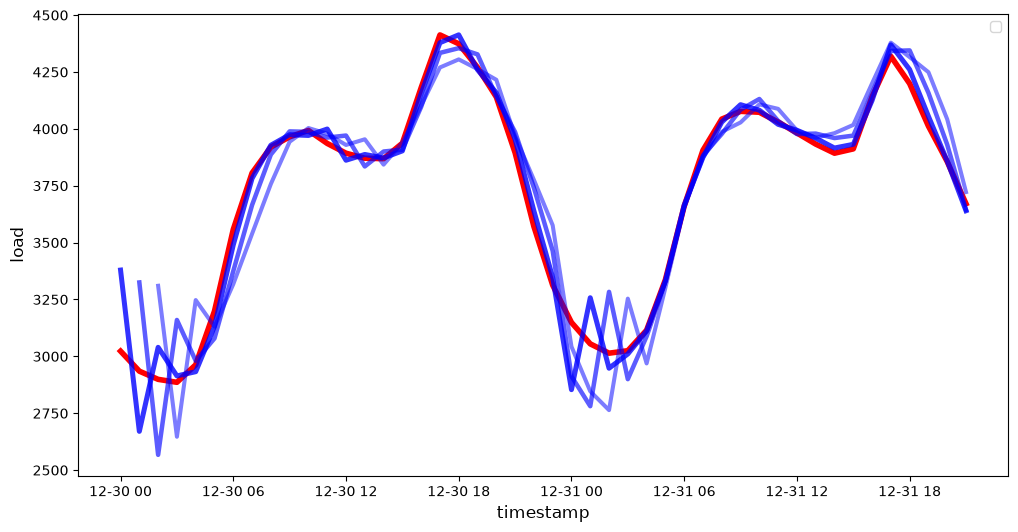

In [31]:
if HORIZON == 1:
    eval_df.plot(x="timestamp", y=["prediction", "actual"], style=["b", "r"], figsize=(12,6))
else:
    plot_df = eval_df[(eval_df.h == "t+1")][["timestamp", "actual"]]
    for t in range(1, HORIZON+1):
        plot_df["t+"+str(t)] = eval_df[(eval_df.h == "t+"+str(t))]["prediction"].values
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(plot_df["timestamp"], plot_df["actual"], color="red", linewidth=4.0)
    for t in range(1, HORIZON+1):
        x = plot_df["timestamp"][t-1:]
        y = plot_df["t+"+str(t)][0:len(x)]
        ax.plot(x, y, color="blue", linewidth=4*math.pow(.9,t), alpha=math.pow(.8,t))
    ax.legend(loc='best')

plt.xlabel("timestamp", fontsize=12)
plt.ylabel("load", fontsize=12)
plt.show()